# CdpCAM MA2024 PC + Cav3p1: NEURON vs BrainCell Cell.run

这个 notebook 在 PC 的 `CdpCAM_MA24_PC.mod` 基础上插入 `Cav3p1_MA24_PC.mod`，检测 T-type Ca current 是否能和 `CdpCAM` calcium-pool / CB / PV / CAM 动力学一起稳定工作。


In [1]:
import os
import sys
import shutil
import subprocess
import tempfile
from pathlib import Path

repo_root = Path('/home/swl/braincell-ion_dyn').resolve()
if str(repo_root) in sys.path:
    sys.path.remove(str(repo_root))
sys.path.insert(0, str(repo_root))

os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np

import braincell
from braincell import Branch, Cell, Morphology
from braincell.filter import BranchSlice, at
from braincell.mech import Channel, CurrentProbe, CurrentClamp, Ion, MechanismProbe, StateProbe
from neuron import h, load_mechanisms

print('braincell version:', braincell.__version__)
print('braincell import path:', Path(braincell.__file__).resolve())

brainstate.environ.set(precision=64)


braincell version: 0.1.0
braincell import path: /home/swl/braincell-ion_dyn/braincell/__init__.py


--No graphics will be displayed.


In [2]:
repo_root = Path(braincell.__file__).resolve().parent.parent
mod_dir = repo_root / 'examples' / 'neuron_compare' / 'Cerebellum_mod' / 'PC'
ion_mod = mod_dir / 'ion' / 'CdpCAM_MA24_PC.mod'
channel_mod = mod_dir / 'channel' / 'Cav3p1_MA24_PC.mod'
print('repo_root:', repo_root)
print('mod_dir:', mod_dir)
print('ion mod exists:', ion_mod.exists())
print('channel mod exists:', channel_mod.exists())

ion_text = ion_mod.read_text()
channel_text = channel_mod.read_text()
print('\nCdpCAM INITIAL block preview:')
print(ion_text.split('INITIAL {', 1)[1].split('}', 1)[0][:1600])
print('\nCav3p1 BREAKPOINT block preview:')
print(channel_text.split('BREAKPOINT {', 1)[1].split('}', 1)[0][:800])


repo_root: /home/swl/braincell-ion_dyn
mod_dir: /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC
ion mod exists: True
channel mod exists: True

CdpCAM INITIAL block preview:

	factors()

	ca = cainull
	mg = mginull
	
	Buff1 = ssBuff1()
	Buff1_ca = ssBuff1ca()

	Buff2 = ssBuff2()
	Buff2_ca = ssBuff2ca()

	BTC = ssBTC()
	BTC_ca = ssBTCca()		

	DMNPE = ssDMNPE()
	DMNPE_ca = ssDMNPEca()

	CB = ssCB( kdf(), kds())   
	CB_f_ca = ssCBfast( kdf(), kds())
	CB_ca_s = ssCBslow( kdf(), kds())
	CB_ca_ca = ssCBca( kdf(), kds())

	PV = ssPV( kdc(), kdm())
	PV_ca = ssPVca(kdc(), kdm())
	PV_mg = ssPVmg(kdc(), kdm())
	
	:Calmodulin
	CAM0	= CAM_start		
	CAM1C	= 0
	CAM2C	= 0
	CAM1N2C = 0
	CAM1N   = 0
	CAM2N	= 0
	CAM2N1C = 0
	CAM1C1N = 0
	CAM4	= 0

		
  	parea = PI*diam
	parea2 = PI*(diam-0.2)
	ica = 0
	ica_pmp = 0
:	ica_pmp_last = 0
	pump = TotalPump
	pumpca = 0
	
	cai = ca
        


Cav3p1 BREAKPOINT block preview:

	SOLVE castate METHOD cnexp 

        ica = (1e3) *pcabar*m*m *h * 

In [3]:
dt_ms = 0.05
duration_ms = 40.0
steps = int(duration_ms / dt_ms)
times_ms = np.arange(steps + 1) * dt_ms

temperature_celsius = 25.0
v_init_mV = -60.0
diam_um = 20.0
length_um = 20.0
stim_delay_ms = 5.0
stim_dur_ms = 20.0
stim_amp_nA = 0.005
pcabar_cm_s = 0.00025

cb_fields = ['CB', 'CB_f_ca', 'CB_ca_s', 'CB_ca_ca']
pv_fields = ['PV', 'PV_ca', 'PV_mg']
cam_fields = [
    'CAM0',
    'CAM1C',
    'CAM2C',
    'CAM1N2C',
    'CAM1N',
    'CAM2N',
    'CAM2N1C',
    'CAM1C1N',
    'CAM4',
]

tracked_fields = ['v', 'Ci', 'ica', 'p', 'q', 'pump', 'pumpca'] + cb_fields + pv_fields + cam_fields
print({
    'dt_ms': dt_ms,
    'duration_ms': duration_ms,
    'temperature_celsius': temperature_celsius,
    'v_init_mV': v_init_mV,
    'length_um': length_um,
    'diam_um': diam_um,
    'stim_delay_ms': stim_delay_ms,
    'stim_dur_ms': stim_dur_ms,
    'stim_amp_nA': stim_amp_nA,
    'pcabar_cm_s': pcabar_cm_s,
    'tracked_fields': tracked_fields,
})


{'dt_ms': 0.05, 'duration_ms': 40.0, 'temperature_celsius': 25.0, 'v_init_mV': -60.0, 'length_um': 20.0, 'diam_um': 20.0, 'stim_delay_ms': 5.0, 'stim_dur_ms': 20.0, 'stim_amp_nA': 0.005, 'pcabar_cm_s': 0.00025, 'tracked_fields': ['v', 'Ci', 'ica', 'p', 'q', 'pump', 'pumpca', 'CB', 'CB_f_ca', 'CB_ca_s', 'CB_ca_ca', 'PV', 'PV_ca', 'PV_mg', 'CAM0', 'CAM1C', 'CAM2C', 'CAM1N2C', 'CAM1N', 'CAM2N', 'CAM2N1C', 'CAM1C1N', 'CAM4']}


In [4]:
compile_cmd = ['nrnivmodl', str(ion_mod), str(channel_mod)]
compile_hint = (
    'Compile the PC ion+channel mechanisms with:\n'
    'tmpdir=$(mktemp -d)\n'
    'cd "$tmpdir"\n'
    'CPP=/usr/bin/cpp CC=/usr/bin/cc CXX=/usr/bin/c++ nrnivmodl ' + str(ion_mod) + ' ' + str(channel_mod) + '\n'
    'If this Python/Jupyter process already loaded an older libnrnmech.so, restart the kernel first.'
)

compiled_mod_dir = None
if compiled_mod_dir is None:
    auto_tmpdir = Path(tempfile.mkdtemp(prefix='cdpcam_cav3p1_'))
    cpp = shutil.which('cpp') or '/usr/bin/cpp'
    cc = shutil.which('cc') or '/usr/bin/cc'
    cxx = shutil.which('c++') or '/usr/bin/c++'
    print('Auto-compiling PC NEURON mods into:', auto_tmpdir)
    proc = subprocess.run(
        compile_cmd,
        cwd=auto_tmpdir,
        env={**os.environ, 'CPP': cpp, 'CC': cc, 'CXX': cxx},
        capture_output=True,
        text=True,
    )
    print(proc.stdout)
    if proc.returncode != 0:
        print(proc.stderr)
        raise RuntimeError(compile_hint)
    compiled_mod_dir = auto_tmpdir
else:
    compiled_mod_dir = Path(compiled_mod_dir)
print('compiled_mod_dir:', compiled_mod_dir)

if not compiled_mod_dir.exists():
    raise RuntimeError(compile_hint)
if not load_mechanisms(str(compiled_mod_dir.resolve())):
    raise RuntimeError(compile_hint)
h.load_file('stdrun.hoc')

sec = h.Section(name='soma')
sec.L = length_um
sec.diam = diam_um
sec.nseg = 1
seg = sec(0.5)
try:
    sec.insert('CdpCAM_MA24_PC')
    sec.insert('Cav3p1_MA24_PC')
except ValueError as exc:
    raise RuntimeError(compile_hint) from exc

ion_mech = seg.CdpCAM_MA24_PC
channel_mech = seg.Cav3p1_MA24_PC
channel_mech.pcabar = pcabar_cm_s

stim = h.IClamp(seg)
stim.delay = stim_delay_ms
stim.dur = stim_dur_ms
stim.amp = stim_amp_nA

h.celsius = temperature_celsius
h.dt = dt_ms
h.steps_per_ms = 1.0 / h.dt
h.tstop = duration_ms
h.v_init = v_init_mV

t_vec = h.Vector().record(h._ref_t)
v_vec = h.Vector().record(seg._ref_v)
cai_vec = h.Vector().record(seg._ref_cai)
ica_vec = h.Vector().record(seg._ref_ica)
pump_vec = h.Vector().record(ion_mech._ref_pump)
pumpca_vec = h.Vector().record(ion_mech._ref_pumpca)
m_vec = h.Vector().record(channel_mech._ref_m)
h_vec = h.Vector().record(channel_mech._ref_h)
cb_vectors = {name: h.Vector().record(getattr(ion_mech, f'_ref_{name}')) for name in cb_fields}
pv_vectors = {name: h.Vector().record(getattr(ion_mech, f'_ref_{name}')) for name in pv_fields}
cam_vectors = {name: h.Vector().record(getattr(ion_mech, f'_ref_{name}')) for name in cam_fields}

h.finitialize(h.v_init)
h.frecord_init()
h.continuerun(h.tstop)

neuron_t_ms = np.asarray(t_vec)
neuron_data = {
    'v': np.asarray(v_vec),
    'Ci': np.asarray(cai_vec),
    'ica': -np.asarray(ica_vec),
    'pump': np.asarray(pump_vec),
    'pumpca': np.asarray(pumpca_vec),
    'p': np.asarray(m_vec),
    'q': np.asarray(h_vec),
}
for name, vec in cb_vectors.items():
    neuron_data[name] = np.asarray(vec)
for name, vec in pv_vectors.items():
    neuron_data[name] = np.asarray(vec)
for name, vec in cam_vectors.items():
    neuron_data[name] = np.asarray(vec)
neuron_total = neuron_data['pump'] + neuron_data['pumpca']

print('max |-NEURON ica|:', float(np.max(np.abs(neuron_data['ica']))))
print('NEURON start/end v:', float(neuron_data['v'][0]), float(neuron_data['v'][-1]))
print('NEURON start/end cai:', float(neuron_data['Ci'][0]), float(neuron_data['Ci'][-1]))
print('NEURON start/end Cav3p1 p/q (from m/h):', float(neuron_data['p'][0]), float(neuron_data['p'][-1]), float(neuron_data['q'][0]), float(neuron_data['q'][-1]))
print('NEURON start/end pump:', float(neuron_data['pump'][0]), float(neuron_data['pump'][-1]))
print('NEURON start/end pumpca:', float(neuron_data['pumpca'][0]), float(neuron_data['pumpca'][-1]))
print('NEURON max pump conserve drift:', float(np.max(np.abs(neuron_total - neuron_total[0]))))
for name in cb_fields + pv_fields + cam_fields:
    arr = neuron_data[name]
    print(f'NEURON {name} start/end:', float(arr[0]), float(arr[-1]))


Auto-compiling PC NEURON mods into: /tmp/cdpcam_cav3p1_qz4y2mih
/tmp/cdpcam_cav3p1_qz4y2mih
Mod files: "/home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/ion//home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/ion/CdpCAM_MA24_PC.mod" "/home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/channel//home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/channel/Cav3p1_MA24_PC.mod"

Creating 'x86_64' directory for .o files.

 -> Compiling mod_func.cpp
 -> NMODL /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/ion/CdpCAM_MA24_PC.mod
 -> NMODL /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/channel/Cav3p1_MA24_PC.mod
 -> Compiling Cav3p1_MA24_PC.c
 -> Compiling CdpCAM_MA24_PC.c
 => LINKING shared library ./libnrnmech.so
 => LINKING executable ./special LDFLAGS are:    -pthread
Successfully created x86_64/special

compiled_mod_dir: /tmp/cdpcam_cav3p1_qz4y2mih
max |-NEURON ica|: 0.009

In [5]:
dt = dt_ms * u.ms
duration = duration_ms * u.ms

soma = Branch.from_lengths(lengths=[length_um] * u.um, radii=[diam_um / 2.0, diam_um / 2.0] * u.um, type='soma')
morpho = Morphology.from_root(soma, name='soma')

cell = Cell(morpho, solver='staggered', V_init=v_init_mV * u.mV)
cell.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    Ion(
        'CdpCAM_MA2024_PC',
        name='ca_cam',
        temp=u.celsius2kelvin(temperature_celsius),
    ),
)
cell.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    Channel(
        'Cav3p1_MA2024_PC',
        ion_name='ca_cam',
        g_max=pcabar_cm_s * (u.cm / u.second),
        temp=u.celsius2kelvin(temperature_celsius),
    ),
)
cell.place(
    at('soma', 0.5),
    StateProbe(),
    CurrentClamp(delay=stim_delay_ms * u.ms, durations=stim_dur_ms * u.ms, amplitudes=stim_amp_nA * u.nA),
    MechanismProbe(mechanism='ca_cam', field='Ci'),
    MechanismProbe(mechanism='ca_cam', field='pump'),
    MechanismProbe(mechanism='ca_cam', field='pumpca'),
    MechanismProbe(mechanism='ca_cam', field='CB'),
    MechanismProbe(mechanism='ca_cam', field='CB_f_ca'),
    MechanismProbe(mechanism='ca_cam', field='CB_ca_s'),
    MechanismProbe(mechanism='ca_cam', field='CB_ca_ca'),
    MechanismProbe(mechanism='ca_cam', field='PV'),
    MechanismProbe(mechanism='ca_cam', field='PV_ca'),
    MechanismProbe(mechanism='ca_cam', field='PV_mg'),
    MechanismProbe(mechanism='ca_cam', field='CAM0'),
    MechanismProbe(mechanism='ca_cam', field='CAM1C'),
    MechanismProbe(mechanism='ca_cam', field='CAM2C'),
    MechanismProbe(mechanism='ca_cam', field='CAM1N2C'),
    MechanismProbe(mechanism='ca_cam', field='CAM1N'),
    MechanismProbe(mechanism='ca_cam', field='CAM2N'),
    MechanismProbe(mechanism='ca_cam', field='CAM2N1C'),
    MechanismProbe(mechanism='ca_cam', field='CAM1C1N'),
    MechanismProbe(mechanism='ca_cam', field='CAM4'),
    MechanismProbe(mechanism='ca_cam', field='vrat'),
    MechanismProbe(mechanism='ca_cam', field='parea'),
    MechanismProbe(mechanism='ca_cam', field='dsq'),
    MechanismProbe(mechanism='ca_cam', field='dsqvol'),
    MechanismProbe(mechanism='Cav3p1_MA2024_PC', field='p'),
    MechanismProbe(mechanism='Cav3p1_MA2024_PC', field='q'),
    CurrentProbe(ion='ca_cam', mechanism='Cav3p1_MA2024_PC'),
)

with brainstate.environ.context(precision=64):
    cell.init_state()
    cell.reset_state()
    print('initial probe v (mV):', float(np.asarray(cell.sample_probe('soma(0.5)_v').to_decimal(u.mV)).reshape(-1)[0]))
    print('initial probe Ci (mM):', float(np.asarray(cell.sample_probe('soma(0.5)_ca_cam_Ci').to_decimal(u.mM)).reshape(-1)[0]))
    print('initial probe Cav3p1 p/q:', float(np.asarray(cell.sample_probe('soma(0.5)_Cav3p1_MA2024_PC_p')).reshape(-1)[0]), float(np.asarray(cell.sample_probe('soma(0.5)_Cav3p1_MA2024_PC_q')).reshape(-1)[0]))
    run_result = cell.run(dt=dt, duration=duration)

cell_data = {
    'v': np.asarray(run_result.traces['soma(0.5)_v'].to_decimal(u.mV)),
    'Ci': np.asarray(run_result.traces['soma(0.5)_ca_cam_Ci'].to_decimal(u.mM)),
    'pump': np.asarray(run_result.traces['soma(0.5)_ca_cam_pump'].to_decimal(u.mol / u.cm ** 2)),
    'pumpca': np.asarray(run_result.traces['soma(0.5)_ca_cam_pumpca'].to_decimal(u.mol / u.cm ** 2)),
    'p': np.asarray(run_result.traces['soma(0.5)_Cav3p1_MA2024_PC_p']),
    'q': np.asarray(run_result.traces['soma(0.5)_Cav3p1_MA2024_PC_q']),
    'ica': np.asarray(run_result.traces['soma(0.5)_Cav3p1_MA2024_PC_current'].to_decimal(u.mA / (u.cm ** 2))),
}
for name in cb_fields + pv_fields + cam_fields:
    cell_data[name] = np.asarray(run_result.traces[f'soma(0.5)_ca_cam_{name}'].to_decimal(u.mM))
cell_geometry = {
    'vrat': np.asarray(run_result.traces['soma(0.5)_ca_cam_vrat']),
    'parea': np.asarray(run_result.traces['soma(0.5)_ca_cam_parea'].to_decimal(u.um)),
    'dsq': np.asarray(run_result.traces['soma(0.5)_ca_cam_dsq'].to_decimal(u.um ** 2)),
    'dsqvol': np.asarray(run_result.traces['soma(0.5)_ca_cam_dsqvol'].to_decimal(u.um ** 2)),
}
cell_total = cell_data['pump'] + cell_data['pumpca']

print('Cell.run max |current|:', float(np.max(np.abs(cell_data['ica']))))
print('Cell.run start/end v:', float(cell_data['v'][0]), float(cell_data['v'][-1]))
print('Cell.run start/end Ci:', float(cell_data['Ci'][0]), float(cell_data['Ci'][-1]))
print('Cell.run start/end Cav3p1 p/q:', float(cell_data['p'][0]), float(cell_data['p'][-1]), float(cell_data['q'][0]), float(cell_data['q'][-1]))
print('Cell.run start/end pump:', float(cell_data['pump'][0]), float(cell_data['pump'][-1]))
print('Cell.run start/end pumpca:', float(cell_data['pumpca'][0]), float(cell_data['pumpca'][-1]))
print('Cell.run max pump conserve drift:', float(np.max(np.abs(cell_total - cell_total[0]))))
for name in cb_fields + pv_fields + cam_fields:
    arr = cell_data[name]
    print(f'Cell.run {name} start/end:', float(arr[0]), float(arr[-1]))
for name, arr in cell_geometry.items():
    print(f'Cell.run {name} first/last:', float(arr[0]), float(arr[-1]))
for name, arr in cell_data.items():
    assert np.isfinite(arr).all(), f'{name} contains non-finite values'


initial probe v (mV): -60.0
initial probe Ci (mM): 4.5e-05
initial probe Cav3p1 p/q: 0.16798161486607552 0.15260866484263105
Cell.run max |current|: 0.009328492886920068
Cell.run start/end v: -59.90221843928582 55.63705262243984
Cell.run start/end Ci: 4.563825823723819e-05 5.4368764474617526e-05
Cell.run start/end Cav3p1 p/q: 0.1679878874591321 0.9998663043187982 0.15260831553583043 0.08205582601002338
Cell.run start/end pump: 9.999999931542922e-10 9.999919350364719e-10
Cell.run start/end pumpca: 6.845707801098757e-18 8.064963528136315e-15
Cell.run max pump conserve drift: 0.0
Cell.run CB start/end: 0.1385187983778799 0.13558794422641288
Cell.run CB_f_ca start/end: 0.013185950699973806 0.013590449813423755
Cell.run CB_ca_s start/end: 0.007574240074675652 0.00983572698321381
Cell.run CB_ca_ca start/end: 0.0007210108474706391 0.0009858789769494245
Cell.run PV start/end: 0.003206605060173741 0.003184851711795265
Cell.run PV_ca start/end: 0.016252489744840014 0.0165452007144665
Cell.run PV

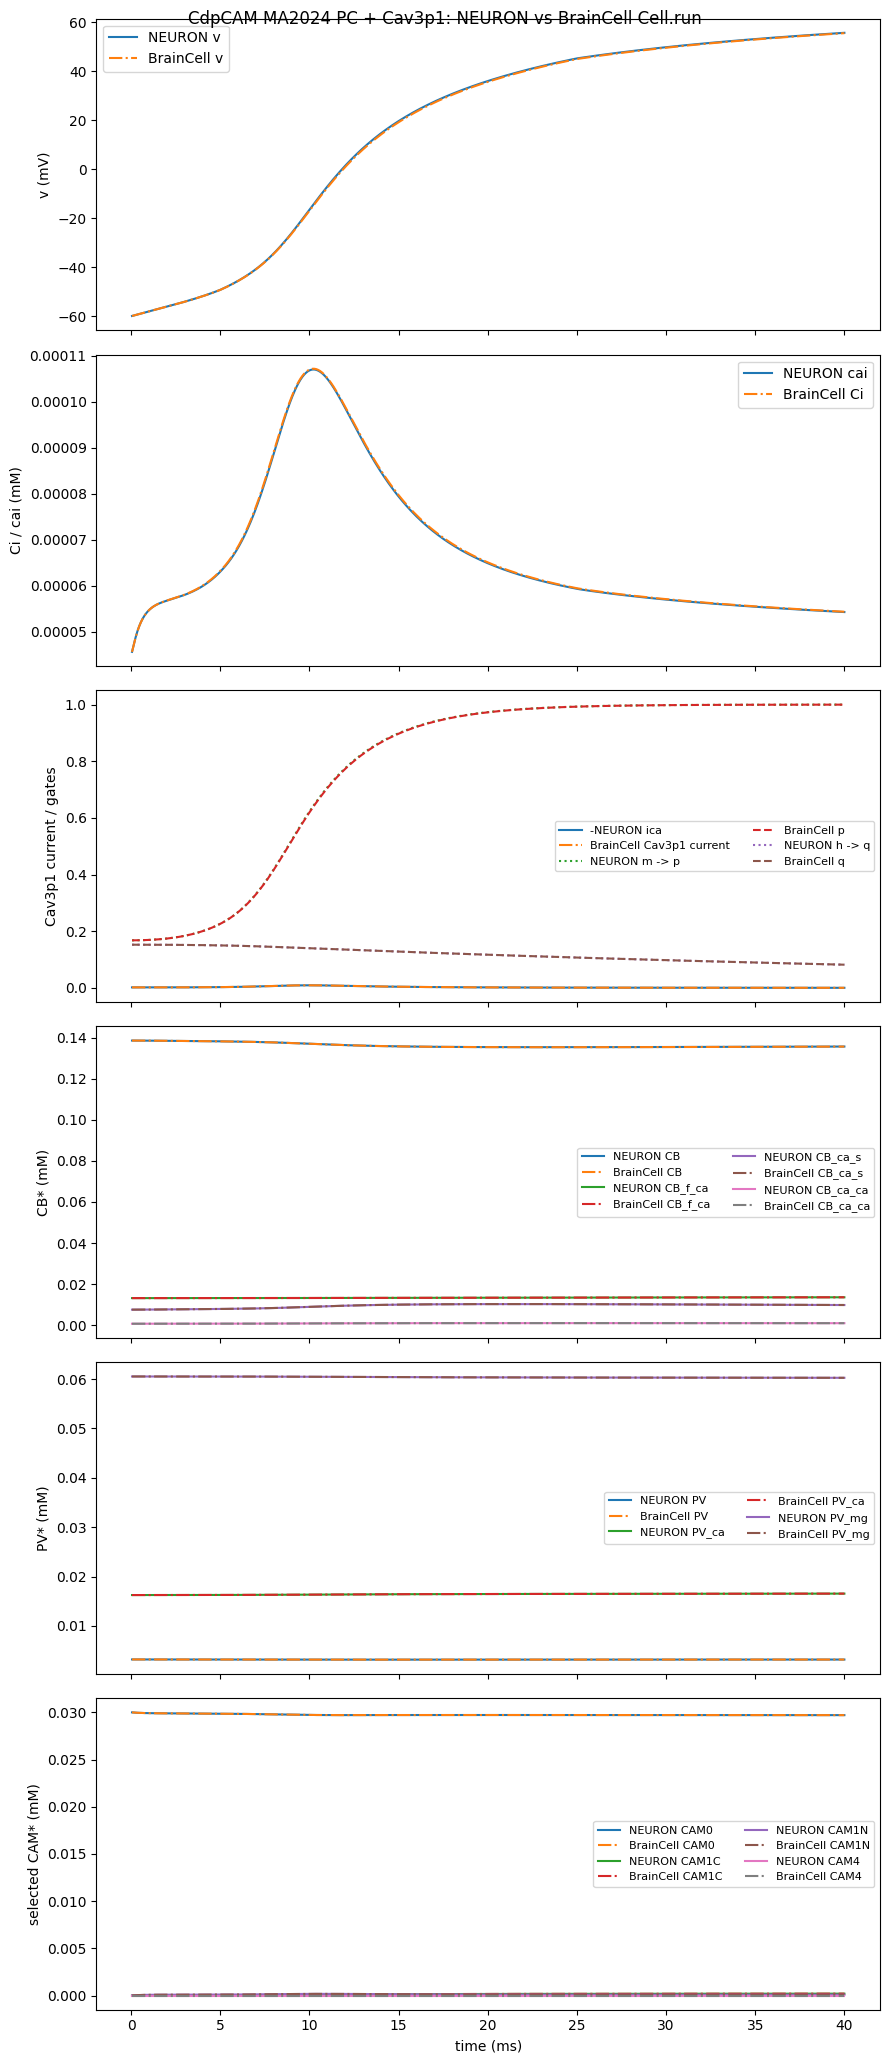

Per-field Cell.run vs NEURON error summary:
v {'mae': 0.23686108281905707, 'rmse': 0.2785632092545487, 'max_abs': 0.5187620642523507}
Ci {'mae': 1.6185658809869178e-07, 'rmse': 1.8999209486265787e-07, 'max_abs': 4.219575520524488e-07}
ica {'mae': 1.93429830361228e-05, 'rmse': 2.546480428656272e-05, 'max_abs': 6.570127742747123e-05}
p {'mae': 0.0007380033915153558, 'rmse': 0.0011827912375436795, 'max_abs': 0.002973048192155825}
q {'mae': 3.06802473607167e-05, 'rmse': 3.325074678187273e-05, 'max_abs': 3.8974620700030216e-05}
pump {'mae': 1.0992852335833413e-17, 'rmse': 1.2782748925268559e-17, 'max_abs': 1.9333084686246843e-17}
pumpca {'mae': 1.0992852276918897e-17, 'rmse': 1.2782748871342909e-17, 'max_abs': 1.9333084556417692e-17}
CB {'mae': 1.632260486040704e-05, 'rmse': 1.8304355731699546e-05, 'max_abs': 2.3125840869581138e-05}
CB_f_ca {'mae': 1.2773251768158595e-06, 'rmse': 1.5710479469383841e-06, 'max_abs': 2.8063106791570425e-06}
CB_ca_s {'mae': 1.3494368462865721e-05, 'rmse': 1.507

In [6]:
compare_t_ms = neuron_t_ms[1:]

def summarize_error(y, ref):
    y = np.asarray(y)
    ref = np.asarray(ref)
    n = min(len(y), len(ref))
    diff = y[:n] - ref[:n]
    return {
        'mae': float(np.mean(np.abs(diff))),
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'max_abs': float(np.max(np.abs(diff))),
    }

error_summary = {}
for name in tracked_fields:
    neuron_cmp = neuron_data[name][1:]
    cell_cmp = cell_data[name]
    error_summary[name] = summarize_error(cell_cmp, neuron_cmp[:len(cell_cmp)])

fig, axes = plt.subplots(6, 1, figsize=(9, 21), sharex=True)

axes[0].plot(compare_t_ms, neuron_data['v'][1:], label='NEURON v')
axes[0].plot(compare_t_ms[:len(cell_data['v'])], cell_data['v'], '-.', label='BrainCell v')
axes[0].set_ylabel('v (mV)')
axes[0].legend()

axes[1].plot(compare_t_ms, neuron_data['Ci'][1:], label='NEURON cai')
axes[1].plot(compare_t_ms[:len(cell_data['Ci'])], cell_data['Ci'], '-.', label='BrainCell Ci')
axes[1].set_ylabel('Ci / cai (mM)')
axes[1].legend()

axes[2].plot(compare_t_ms, neuron_data['ica'][1:], label='-NEURON ica')
axes[2].plot(compare_t_ms[:len(cell_data['ica'])], cell_data['ica'], '-.', label='BrainCell Cav3p1 current')
axes[2].plot(compare_t_ms, neuron_data['p'][1:], ':', label='NEURON m -> p')
axes[2].plot(compare_t_ms[:len(cell_data['p'])], cell_data['p'], '--', label='BrainCell p')
axes[2].plot(compare_t_ms, neuron_data['q'][1:], ':', label='NEURON h -> q')
axes[2].plot(compare_t_ms[:len(cell_data['q'])], cell_data['q'], '--', label='BrainCell q')
axes[2].set_ylabel('Cav3p1 current / gates')
axes[2].legend(ncol=2, fontsize=8)

for name in cb_fields:
    axes[3].plot(compare_t_ms, neuron_data[name][1:], label=f'NEURON {name}')
    axes[3].plot(compare_t_ms[:len(cell_data[name])], cell_data[name], '-.', label=f'BrainCell {name}')
axes[3].set_ylabel('CB* (mM)')
axes[3].legend(ncol=2, fontsize=8)

for name in pv_fields:
    axes[4].plot(compare_t_ms, neuron_data[name][1:], label=f'NEURON {name}')
    axes[4].plot(compare_t_ms[:len(cell_data[name])], cell_data[name], '-.', label=f'BrainCell {name}')
axes[4].set_ylabel('PV* (mM)')
axes[4].legend(ncol=2, fontsize=8)

for name in ['CAM0', 'CAM1C', 'CAM1N', 'CAM4']:
    axes[5].plot(compare_t_ms, neuron_data[name][1:], label=f'NEURON {name}')
    axes[5].plot(compare_t_ms[:len(cell_data[name])], cell_data[name], '-.', label=f'BrainCell {name}')
axes[5].set_xlabel('time (ms)')
axes[5].set_ylabel('selected CAM* (mM)')
axes[5].legend(ncol=2, fontsize=8)

plt.suptitle('CdpCAM MA2024 PC + Cav3p1: NEURON vs BrainCell Cell.run')
plt.tight_layout()
plt.show()

print('Per-field Cell.run vs NEURON error summary:')
for name in tracked_fields:
    print(name, error_summary[name])

print('\nPump conserve drift:')
print('  NEURON:', float(np.max(np.abs(neuron_total - neuron_total[0]))))
print('  BrainCell Cell.run:', float(np.max(np.abs(cell_total - cell_total[0]))))

print('\nCa current nonzero check:')
print('  max |-NEURON ica|:', float(np.max(np.abs(neuron_data['ica']))))
print('  max |BrainCell current|:', float(np.max(np.abs(cell_data['ica']))))

print('\nExtra CAM* end-state comparison:')
for name in ['CAM2C', 'CAM1N2C', 'CAM2N', 'CAM2N1C', 'CAM1C1N']:
    print(
        name,
        {
            'NEURON_end': float(neuron_data[name][-1]),
            'cell_end': float(cell_data[name][-1]),
        },
    )
